# Presentation figures

Slide-ready figures for the PostgreSQL energy/runtime study, saved as PNGs in
**`./presentation/`**. Runtime **and** energy are shown for every figure unless
noted. Each plot uses **PostgreSQL 18** by default — change the `PG_MAJOR`
(or `SCALE`) variable at the top of a cell to re-target it.

Every figure is saved **twice**: a **log** y-scale version (`figN_…​.png`) and a
**linear** y-scale version (`figN_…​_linear.png`), since a log axis compresses
the big-query outliers and can be hard to read on a slide. The **linear**
versions **omit the outlier dots** (points beyond 1.5×IQR) so the boxes / bulk of
the data stay readable; the log versions show every point.

Data sources (read from local caches — run the sweep notebooks to refresh):
* **Scaling / versions / warm-cold** — `csv_cache/` (the full tpch suite at
  scale factors SF1/SF2/SF5, all PG versions, warm + cold).
* **Parameters / indexing** — the per-parameter caches (`sb_cache/`, `ecs_cache/`,
  …) on the **tpch-queries** set (~53 queries).

In [1]:
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

OUT = Path("presentation"); OUT.mkdir(exist_ok=True)
CACHE = Path("csv_cache")                       # top-level scale data
SCALES = {"tpch": "SF1", "tpch2": "SF2", "tpch5": "SF5"}
C_RUN, C_ENE = "#4c72b0", "#dd8452"
C_WARM, C_COLD = "#4c72b0", "#55a868"

# per-parameter specs (kind: mem/memkb/num/count -> scatter; cat -> boxplot)
PARAMS = [
    dict(name="shared_buffers", cache="sb_cache", prefix="sb", kind="mem", temp="warm"),
    dict(name="effective_cache_size", cache="ecs_cache", prefix="ecs", kind="mem", temp="warm"),
    dict(name="work_mem", cache="wm_cache", prefix="wm", kind="mem", temp="warm"),
    dict(name="hash_mem_multiplier", cache="hmm_cache", prefix="hmm", kind="num", temp="warm"),
    dict(name="max_parallel_workers_per_gather", cache="mpw_cache", prefix="mpw", kind="count", temp="warm"),
    dict(name="effective_io_concurrency", cache="eic_cache", prefix="eic", kind="count", temp="cold"),
    dict(name="io_combine_limit", cache="iocl_cache", prefix="iocl", kind="memkb", temp="cold"),
    dict(name="io_method", cache="iom_cache", prefix="iom", kind="cat", temp="cold",
         order=["sync", "worker_io1", "worker_io3", "worker_io6", "io_uring"],
         labels={"sync": "sync", "worker_io1": "worker\nio1", "worker_io3": "worker\nio3",
                 "worker_io6": "worker\nio6", "io_uring": "io_uring"}),
    dict(name="parallel_leader_participation", cache="plp_cache", prefix="plp", kind="cat", temp="warm",
         order=["on", "off"], labels={"on": "on", "off": "off"}),
]


def ver_major(s):
    return str(s).split(".")[0]


def savefig(fig, name):
    p = OUT / f"{name}.png"
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print("saved", p)
    plt.show()


# ---- per-query reductions (mirror the sweep notebooks) ----
def warm_per_query(tim):
    m = tim[tim["phase"] == "measured"].copy()
    for c in ["batchnum", "avg_copy_elapsed_sec", "rapl_pkg_j", "failed"]:
        m[c] = pd.to_numeric(m[c], errors="coerce")
    m = m[m["failed"].fillna(0) == 0]
    bn = m["batchnum"].replace(0, np.nan)
    m["t"] = m["avg_copy_elapsed_sec"]
    m["e"] = (m["rapl_pkg_j"] / bn).mask(lambda s: s < 0)
    return m.groupby("query", as_index=False).agg(t=("t", "mean"), e=("e", "mean"))


def cold_per_query(cr):
    c = cr.copy()
    for col in ["elapsed_sec", "rapl_pkg_j", "failed"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")
    c = c[c["failed"].fillna(0) == 0]
    c["t"] = c["elapsed_sec"]
    c["e"] = c["rapl_pkg_j"].mask(lambda s: s < 0)
    return c.groupby("query", as_index=False).agg(t=("t", "mean"), e=("e", "mean"))


def load_scale(scale, temp, major=None):
    f = CACHE / (f"query_timing_{scale}.csv" if temp == "warm" else f"query_cold_{scale}.csv")
    if not f.exists():
        return None
    d = pd.read_csv(f)
    if major:
        d = d[d["pg_version"].map(ver_major) == str(major)]
    if not len(d):
        return None
    return warm_per_query(d) if temp == "warm" else cold_per_query(d)


# ---- parameter parsing / loading (tpch-queries set) ----
def parse_num(name, prefix, kind, order=None, labels=None):
    if kind == "cat":
        m = re.match(rf"{prefix}_(.+)$", name)
        if not m:
            return None, None
        k = m.group(1)
        if order and k not in order:
            return None, None
        return (order.index(k) if order else 0), (labels.get(k, k) if labels else k)
    if kind == "mem":
        m = re.match(rf"{prefix}_(\d+)(MB|GB)$", name)
        if not m:
            return None, None
        v, u = int(m.group(1)), m.group(2)
        mb = v * 1024 if u == "GB" else v
        return mb, (f"{mb // 1024} GB" if mb >= 1024 and mb % 1024 == 0 else f"{mb} MB")
    if kind == "memkb":
        m = re.match(rf"{prefix}_(\d+)(kB|MB|GB)$", name)
        if not m:
            return None, None
        v, u = int(m.group(1)), m.group(2)
        kb = v * (1 if u == "kB" else 1024 if u == "MB" else 1048576)
        lab = (f"{kb // 1048576} GB" if kb >= 1048576 and kb % 1048576 == 0
               else f"{kb // 1024} MB" if kb >= 1024 and kb % 1024 == 0 else f"{kb} kB")
        return kb, lab
    m = re.match(rf"{prefix}_(\d+(?:\.\d+)?)$", name)      # num / count
    if not m:
        return None, None
    v = float(m.group(1))
    return v, (str(int(v)) if v == int(v) else str(v))


def load_param(cfg, major=None):
    cdir = Path(cfg["cache"])
    if not cdir.exists():
        return None
    rows = []
    for folder in sorted(p for p in cdir.iterdir() if p.is_dir()):
        val, lab = parse_num(folder.name, cfg["prefix"], cfg["kind"],
                             cfg.get("order"), cfg.get("labels"))
        if val is None:
            continue
        f = folder / ("query_timing_tpch.csv" if cfg["temp"] == "warm" else "query_cold_tpch.csv")
        if not f.exists():
            continue
        d = pd.read_csv(f)
        if major:
            d = d[d["pg_version"].map(ver_major) == str(major)]
        if not len(d):
            continue
        g = warm_per_query(d) if cfg["temp"] == "warm" else cold_per_query(d)
        g["value"] = val
        g["label"] = lab
        rows.append(g)
    return pd.concat(rows, ignore_index=True) if rows else None


# ---- plot helpers ----
def box(ax, groups, labels, ylabel, color, logy=True):
    groups = [np.asarray(g, dtype=float) for g in groups]
    groups = [g[~np.isnan(g)] for g in groups]
    bp = ax.boxplot(groups, showfliers=logy, patch_artist=True, widths=0.6,
                    medianprops=dict(color="black"),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4,
                                    markerfacecolor="0.35", markeredgecolor="none"))
    cols = color if isinstance(color, (list, tuple)) and len(color) == len(groups) else [color] * len(groups)
    for b, c in zip(bp["boxes"], cols):
        b.set(facecolor=c, alpha=0.6)
    ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels)
    if logy:
        ax.set_yscale("log")
    ax.set_ylabel(ylabel); ax.grid(axis="y", linestyle=":", alpha=0.5)


def scatter_fit(ax, dfp, col, ylabel, color, logy=True, degree=2):
    # settings on an evenly-spaced categorical axis (so the linear version has no
    # log anywhere); every query is a dot in the strip above its setting; the
    # best fit is a polynomial (degree>1 -> curved) through those points.
    d = dfp[(dfp[col] > 0)].dropna(subset=[col]).copy()
    if not logy:                                     # drop outlier dots on linear
        yv = d[col].to_numpy(float)
        q1, q3 = np.percentile(yv, [25, 75]); iqr = q3 - q1
        d = d[(d[col] >= q1 - 1.5 * iqr) & (d[col] <= q3 + 1.5 * iqr)]
    uvals = sorted(d["value"].unique())
    pos = {v: i for i, v in enumerate(uvals)}
    xs = d["value"].map(pos).to_numpy(float)
    ys = d[col].to_numpy(float)
    for i in range(len(uvals)):
        yy = ys[xs == i]
        ax.scatter(np.full(len(yy), i), yy, s=12, alpha=0.35, color=color, edgecolors="none")
    deg = max(1, min(degree, len(uvals) - 1))
    yt = np.log10(ys) if logy else ys
    c = np.polyfit(xs, yt, deg)
    xl = np.linspace(0, len(uvals) - 1, 200)
    yl = np.polyval(c, xl)
    ax.plot(xl, 10 ** yl if logy else yl, color="black", lw=2, ls="--",
            label="best fit" if deg == 1 else f"best fit (deg {deg})")
    if logy:
        ax.set_yscale("log")
    ax.set_xticks(range(len(uvals)))
    ax.set_xticklabels([d[d["value"] == v]["label"].iloc[0] for v in uvals])
    ax.set_ylabel(ylabel); ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)


def warm_components(scale, major):
    tim = pd.read_csv(CACHE / f"query_timing_{scale}.csv")
    samp = pd.read_csv(CACHE / f"query_samples_{scale}.csv")
    tim = tim[tim["phase"] == "measured"]; samp = samp[samp["phase"] == "measured"]
    if major:
        tim = tim[tim["pg_version"].map(ver_major) == str(major)]
        samp = samp[samp["pg_version"].map(ver_major) == str(major)]
    for c in ["batchnum", "server_sum_ms", "client_overhead_sec", "failed"]:
        tim[c] = pd.to_numeric(tim[c], errors="coerce")
    tim = tim[tim["failed"].fillna(0) == 0]
    bn = tim["batchnum"].replace(0, np.nan)
    tim["srv"] = (tim["server_sum_ms"] / 1000) / bn
    tim["oh"] = tim["client_overhead_sec"] / bn
    T = tim.groupby("query").agg(srv=("srv", "mean"), oh=("oh", "mean"))
    for c in ["server_planning_ms", "server_execution_ms"]:
        samp[c] = pd.to_numeric(samp[c], errors="coerce")
    S = samp.groupby("query").agg(pl=("server_planning_ms", "mean"), ex=("server_execution_ms", "mean"))
    m = T.join(S, how="inner")
    ratio = (m["pl"] / (m["pl"] + m["ex"])).fillna(0.0)
    m["plan_s"] = m["srv"] * ratio
    m["exec_s"] = m["srv"] * (1 - ratio)
    return m[["plan_s", "exec_s", "oh"]].mean()


def cold_components(scale, major):
    c = pd.read_csv(CACHE / f"query_cold_{scale}.csv")
    if major:
        c = c[c["pg_version"].map(ver_major) == str(major)]
    for col in ["server_planning_ms", "server_execution_ms", "client_overhead_sec", "failed"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")
    c = c[c["failed"].fillna(0) == 0]
    c["plan_s"] = c["server_planning_ms"] / 1000
    c["exec_s"] = c["server_execution_ms"] / 1000
    c["oh"] = c["client_overhead_sec"]
    g = c.groupby("query").agg(plan_s=("plan_s", "mean"), exec_s=("exec_s", "mean"), oh=("oh", "mean"))
    return g[["plan_s", "exec_s", "oh"]].mean()


print("setup ready; caches present:",
      [c for c in ["csv_cache"] + [p["cache"] for p in PARAMS] if Path(c).exists()])

setup ready; caches present: ['csv_cache', 'sb_cache', 'ecs_cache', 'wm_cache', 'hmm_cache', 'mpw_cache', 'eic_cache', 'iocl_cache', 'iom_cache', 'plp_cache']


## 1. TPC-H scaling — per-query distribution at each scale factor

Boxplots (median, IQR box, 1.5×IQR whiskers, outlier dots) of the per-query
**runtime** and **energy** at SF1 / SF2 / SF5. Warm and cold are saved as separate
figures. `PG_MAJOR` selects the PostgreSQL version.

saved presentation\fig1_scaling_warm.png


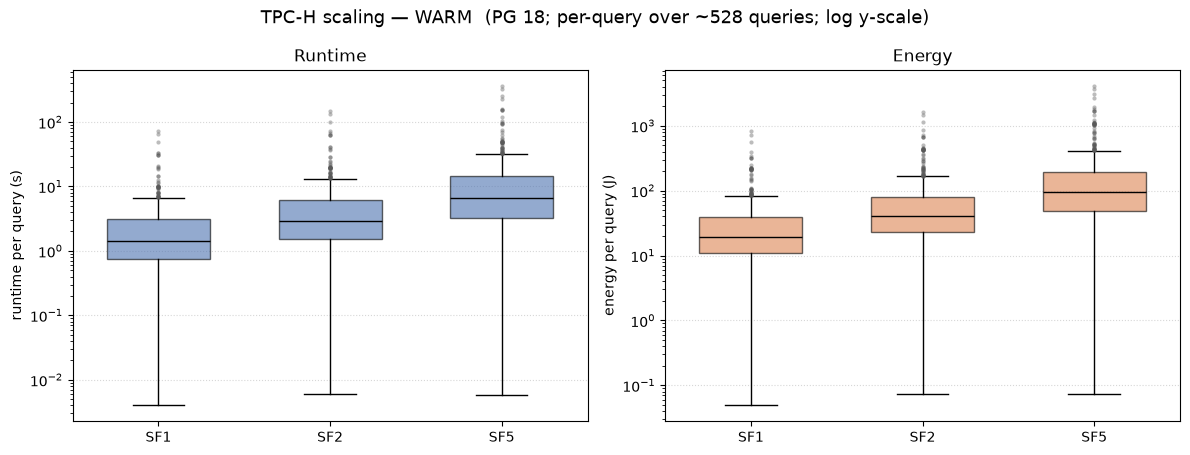

saved presentation\fig1_scaling_warm_linear.png


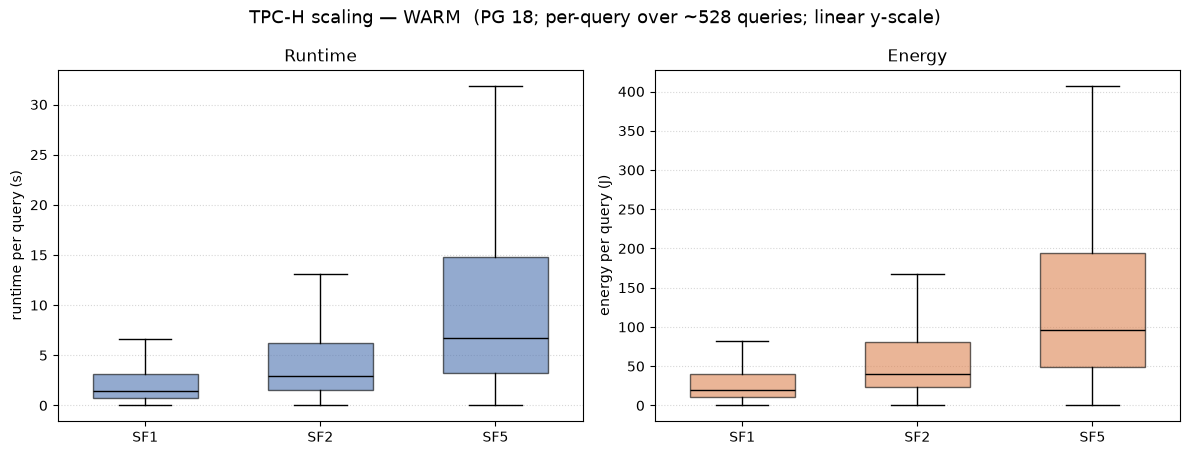

saved presentation\fig1_scaling_cold.png


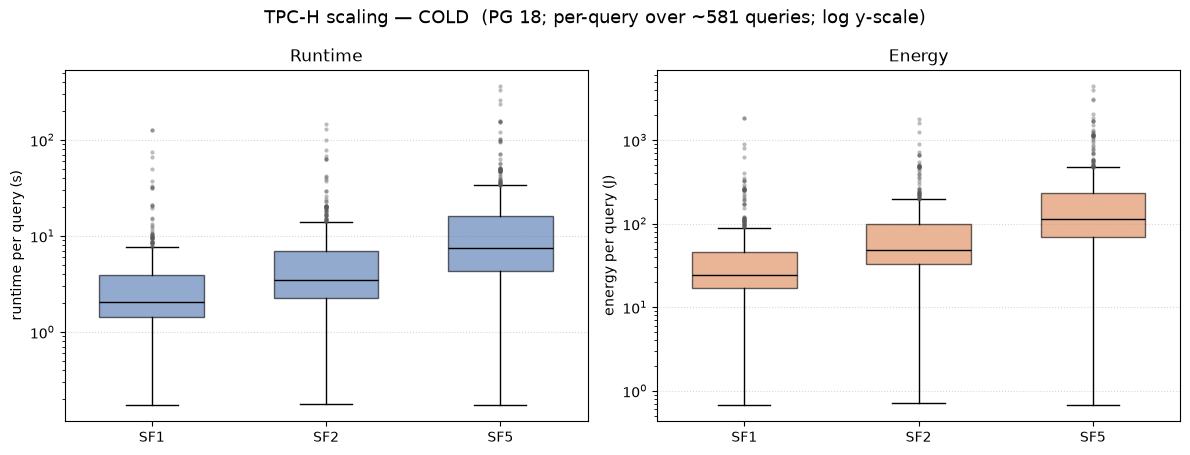

saved presentation\fig1_scaling_cold_linear.png


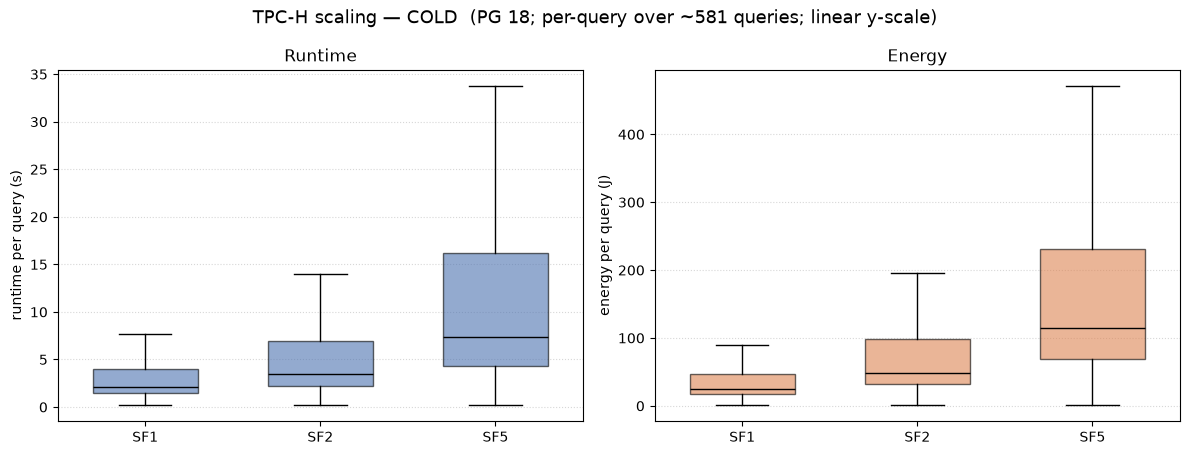

In [2]:
PG_MAJOR = "18"        # <-- change to "14" / "16" for other versions

for temp in ["warm", "cold"]:
    data = {s: load_scale(s, temp, PG_MAJOR) for s in SCALES}
    data = {s: d for s, d in data.items() if d is not None and len(d)}
    if not data:
        print(f"no {temp} scale data"); continue
    labels = [SCALES[s] for s in data]
    n = max(len(data[s]) for s in data)
    for logy in (True, False):                       # log-scale + linear-scale versions
        suffix, sc = ("", "log") if logy else ("_linear", "linear")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
        box(axes[0], [data[s]["t"].to_numpy() for s in data], labels, "runtime per query (s)", C_RUN, logy=logy)
        box(axes[1], [data[s]["e"].to_numpy() for s in data], labels, "energy per query (J)", C_ENE, logy=logy)
        axes[0].set_title("Runtime"); axes[1].set_title("Energy")
        fig.suptitle(f"TPC-H scaling — {temp.upper()}  (PG {PG_MAJOR}; per-query over ~{n} queries; {sc} y-scale)",
                     fontsize=13)
        fig.tight_layout(); savefig(fig, f"fig1_scaling_{temp}{suffix}")

## 2. PostgreSQL versions — per-query distribution at a fixed scale

Boxes are PG 14 / 16 / 18 at one scale factor (`SCALE`). Warm and cold saved
separately. (Version is the variable here, so this cell sweeps versions rather
than fixing one.)

saved presentation\fig2_versions_warm.png


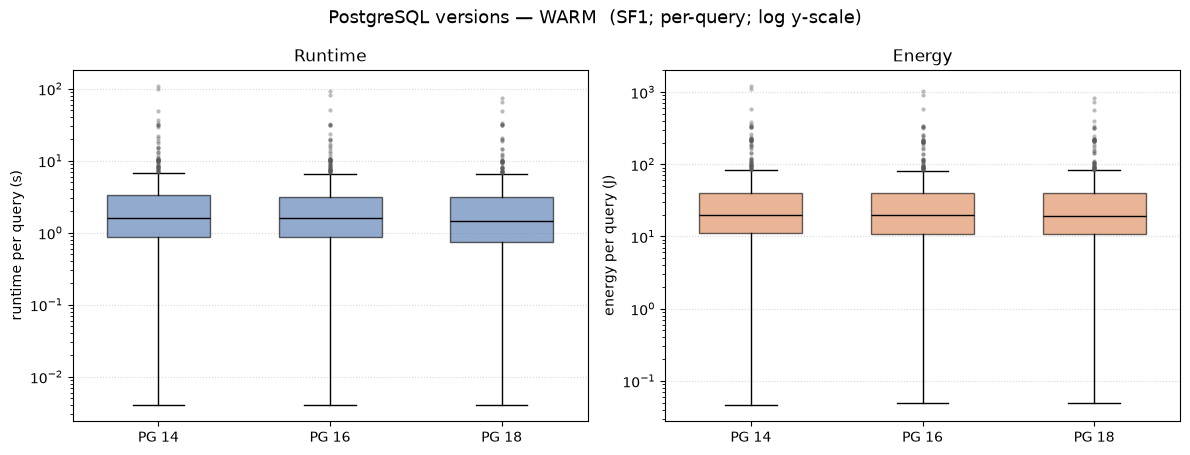

saved presentation\fig2_versions_warm_linear.png


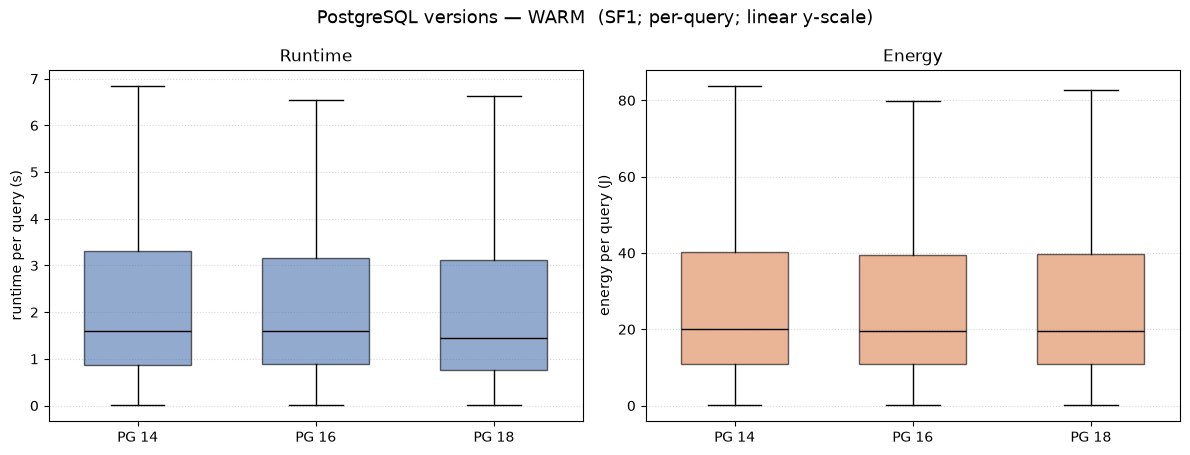

saved presentation\fig2_versions_cold.png


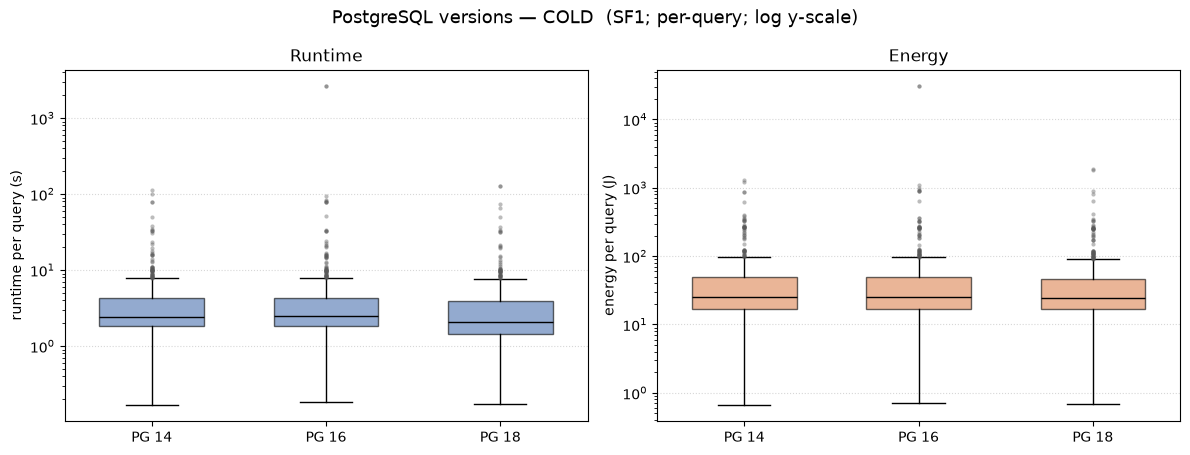

saved presentation\fig2_versions_cold_linear.png


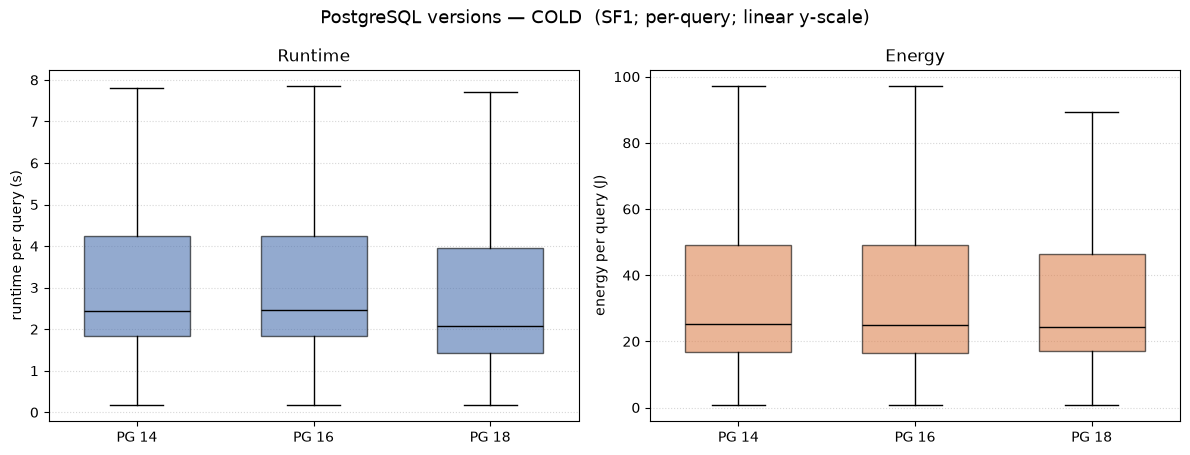

In [3]:
SCALE = "tpch"          # <-- SF1; change to "tpch2" / "tpch5"
MAJORS = ["14", "16", "18"]

for temp in ["warm", "cold"]:
    gt, ge, labs = [], [], []
    for mj in MAJORS:
        d = load_scale(SCALE, temp, mj)
        if d is None or not len(d):
            continue
        gt.append(d["t"].to_numpy()); ge.append(d["e"].to_numpy()); labs.append(f"PG {mj}")
    if not labs:
        print(f"no {temp} data for {SCALE}"); continue
    for logy in (True, False):
        suffix, sc = ("", "log") if logy else ("_linear", "linear")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
        box(axes[0], gt, labs, "runtime per query (s)", C_RUN, logy=logy)
        box(axes[1], ge, labs, "energy per query (J)", C_ENE, logy=logy)
        axes[0].set_title("Runtime"); axes[1].set_title("Energy")
        fig.suptitle(f"PostgreSQL versions — {temp.upper()}  ({SCALES.get(SCALE, SCALE)}; per-query; {sc} y-scale)",
                     fontsize=13)
        fig.tight_layout(); savefig(fig, f"fig2_versions_{temp}{suffix}")

## 3. Database parameters — one figure per parameter (tpch-queries set)

For a **single-valued** parameter (shared_buffers, work_mem, …) each query is a
dot in a vertical strip above its setting, with a **best-fit** trend line — a
polynomial of degree `FIT_DEGREE` (default 2, so it can **curve**; set to 1 for a
straight line). For a **categorical** parameter (io_method,
parallel_leader_participation) each setting gets a **boxplot**. Runtime + energy,
log and linear y-scale. Parameters with no cache yet are skipped.

saved presentation\fig3_sb.png


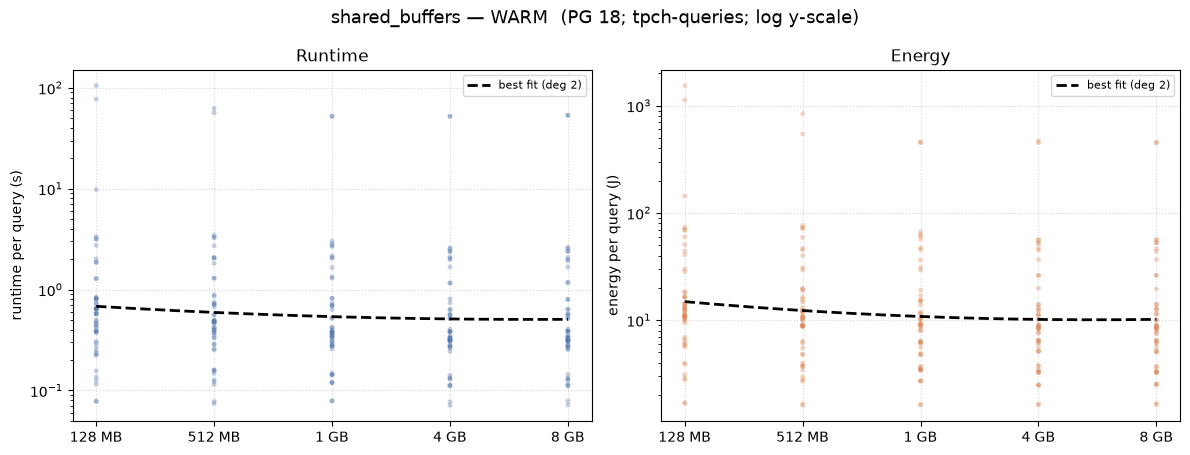

saved presentation\fig3_sb_linear.png


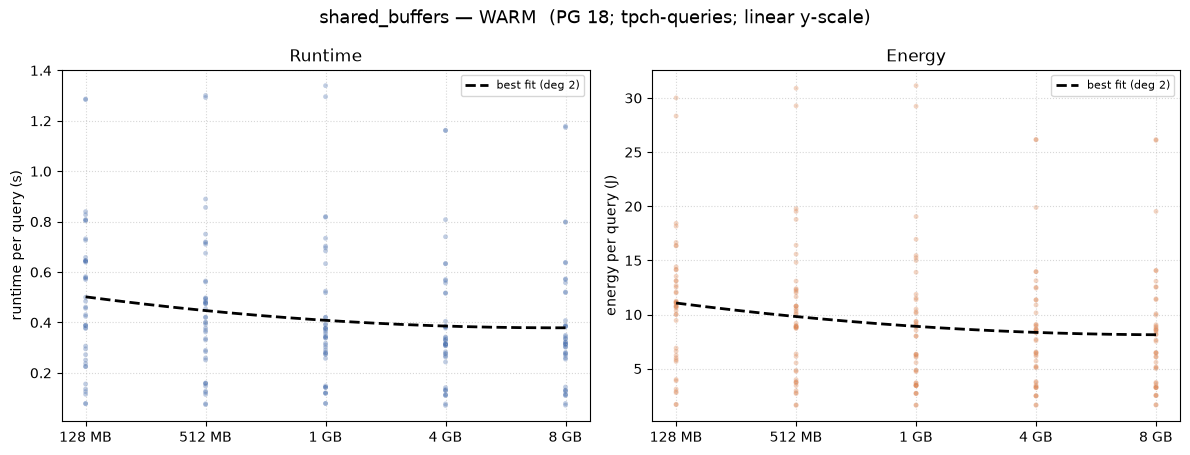

saved presentation\fig3_ecs.png


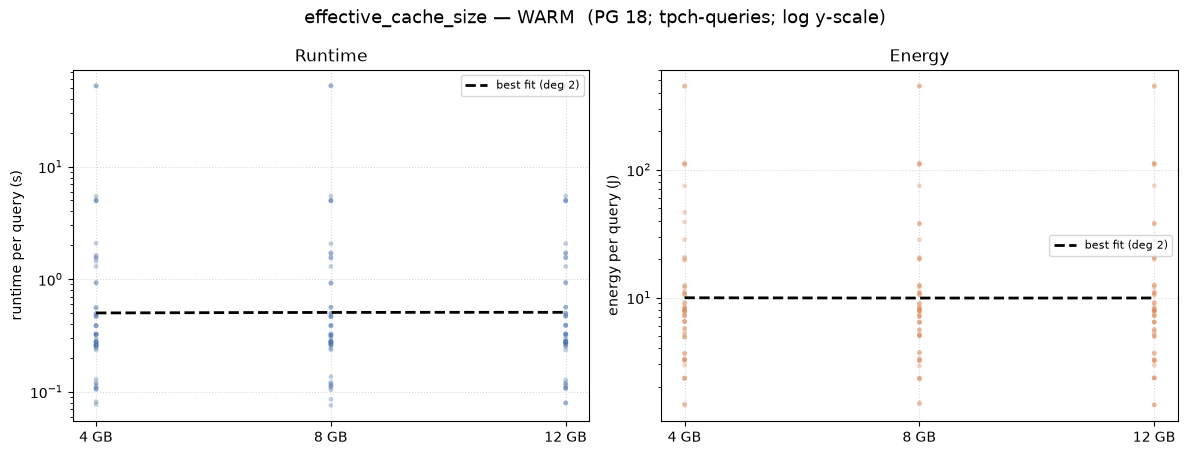

saved presentation\fig3_ecs_linear.png


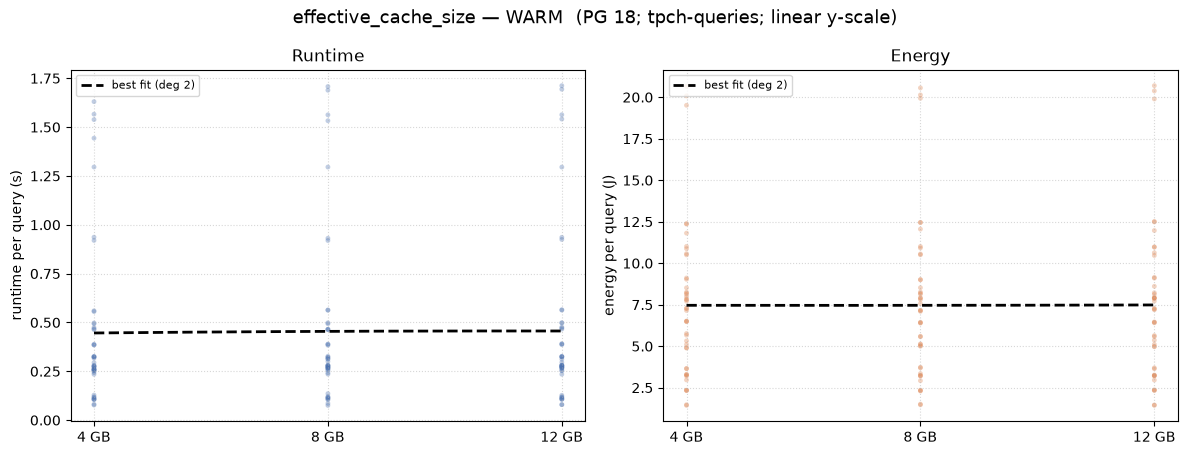

saved presentation\fig3_wm.png


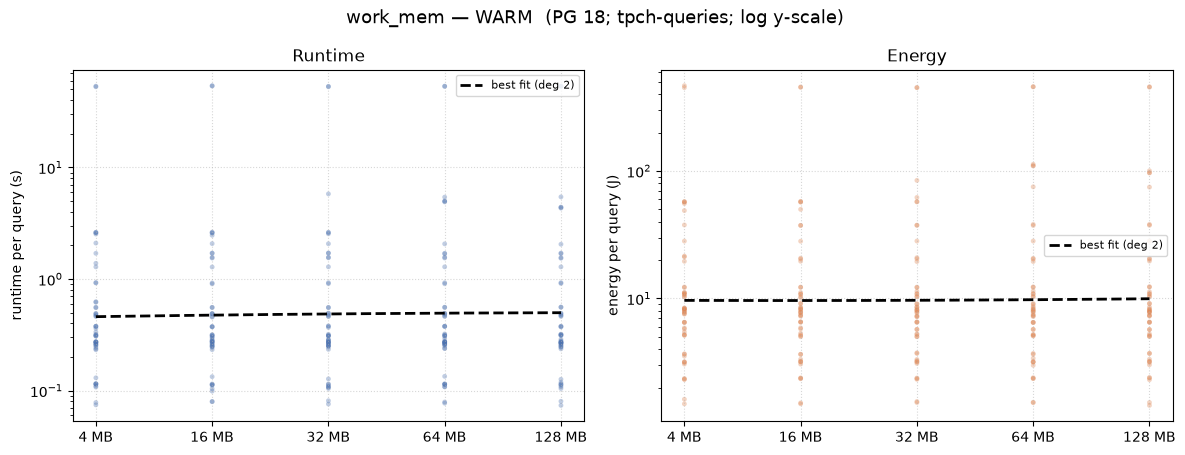

saved presentation\fig3_wm_linear.png


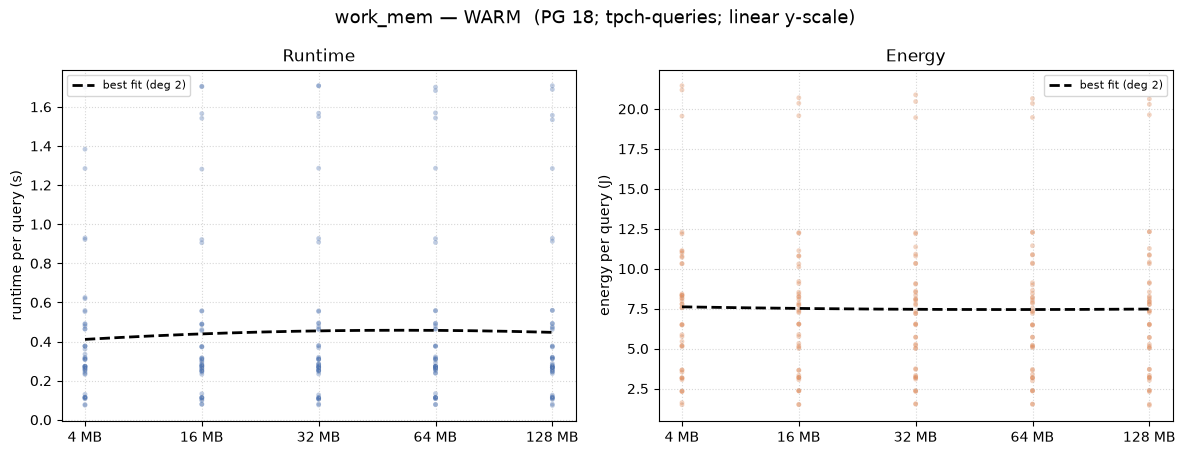

saved presentation\fig3_hmm.png


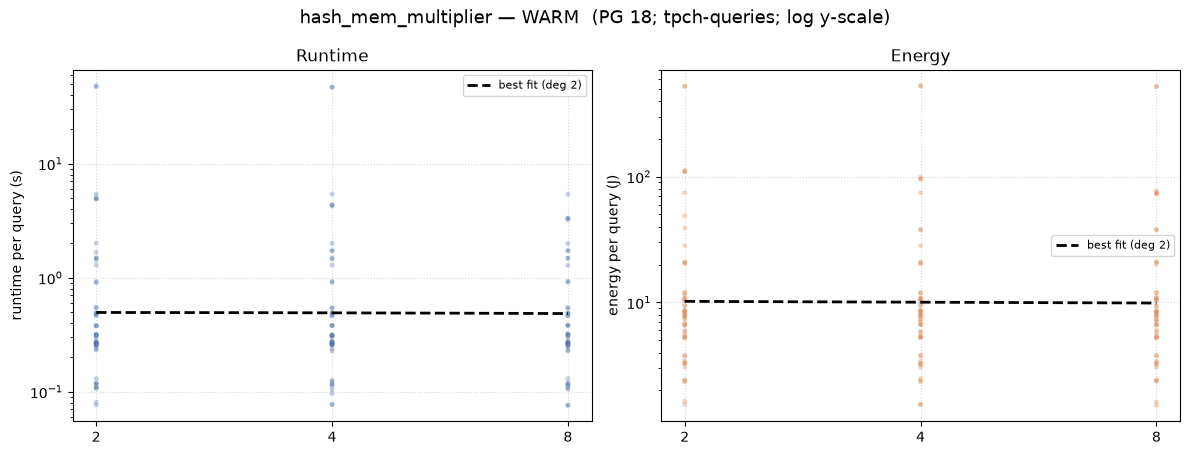

saved presentation\fig3_hmm_linear.png


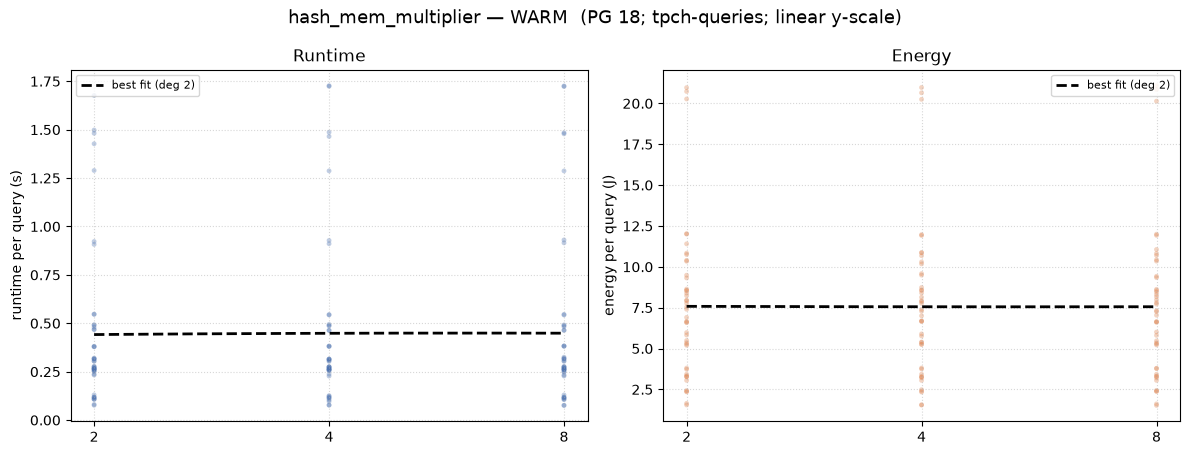

saved presentation\fig3_mpw.png


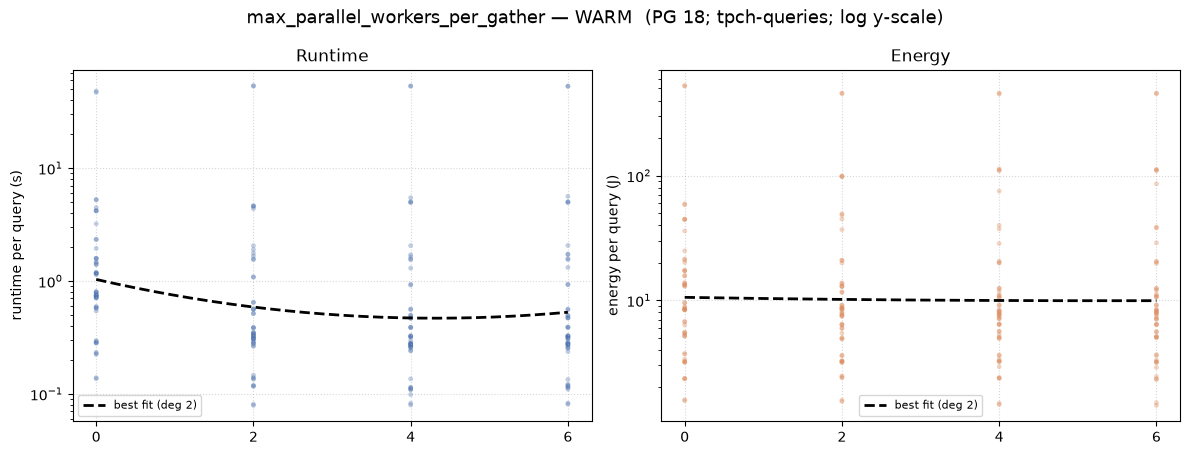

saved presentation\fig3_mpw_linear.png


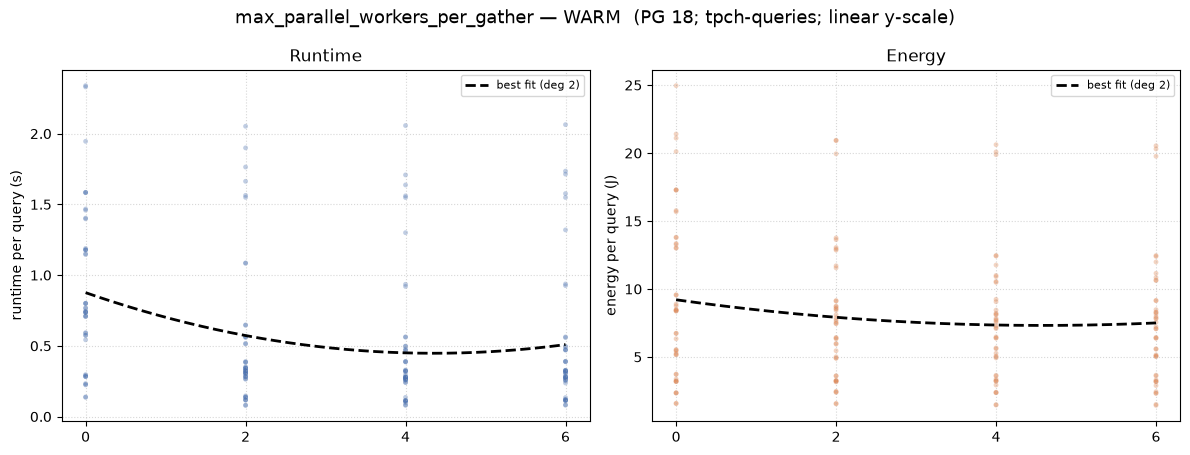

saved presentation\fig3_eic.png


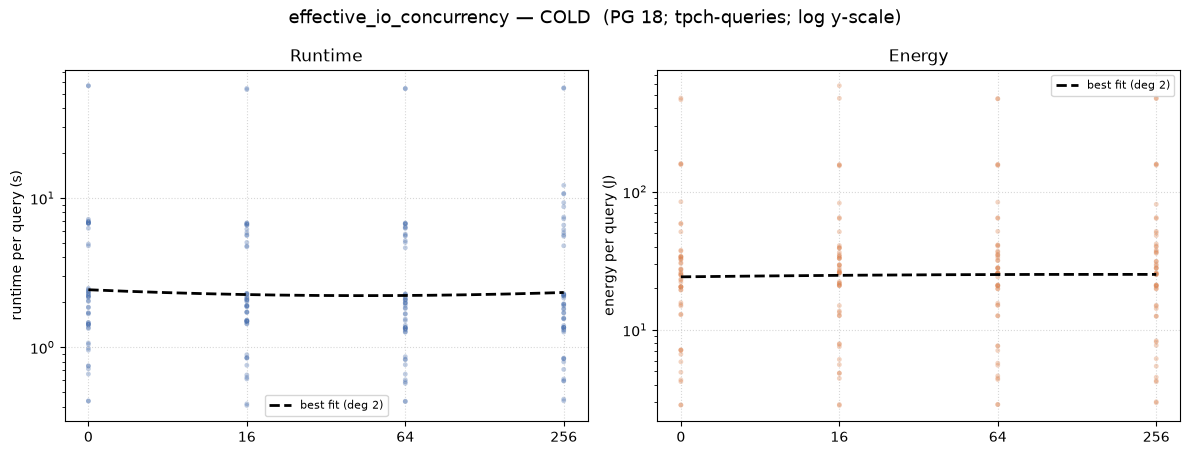

saved presentation\fig3_eic_linear.png


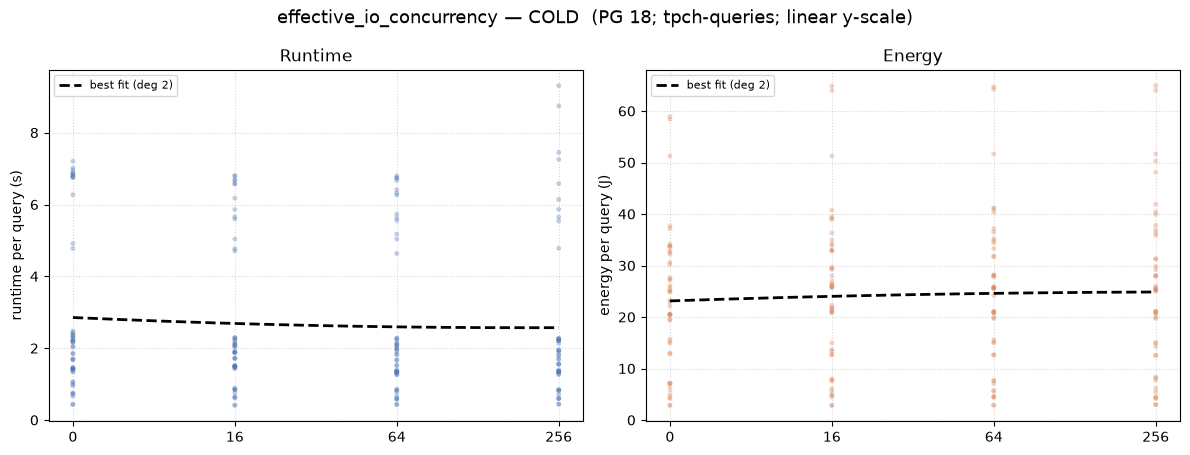

saved presentation\fig3_iocl.png


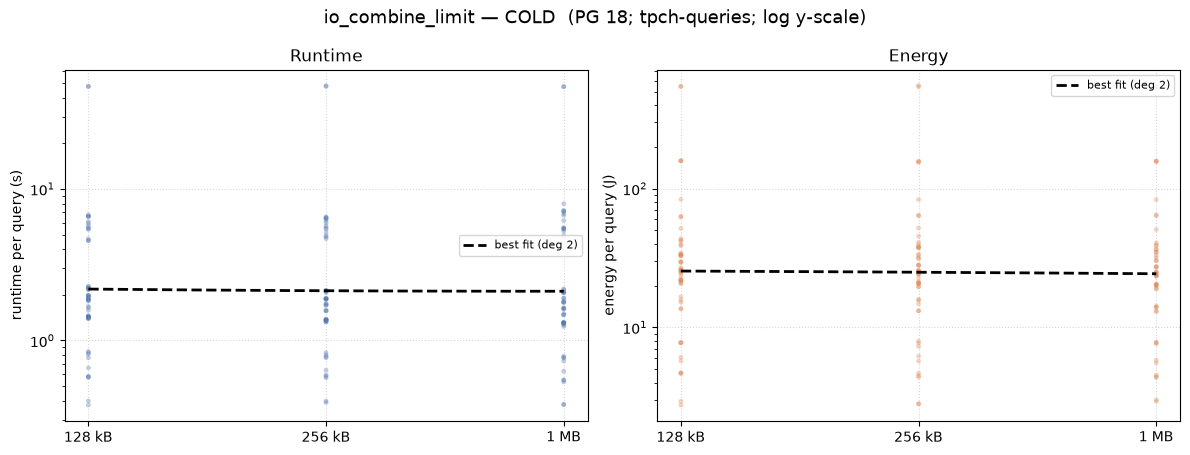

saved presentation\fig3_iocl_linear.png


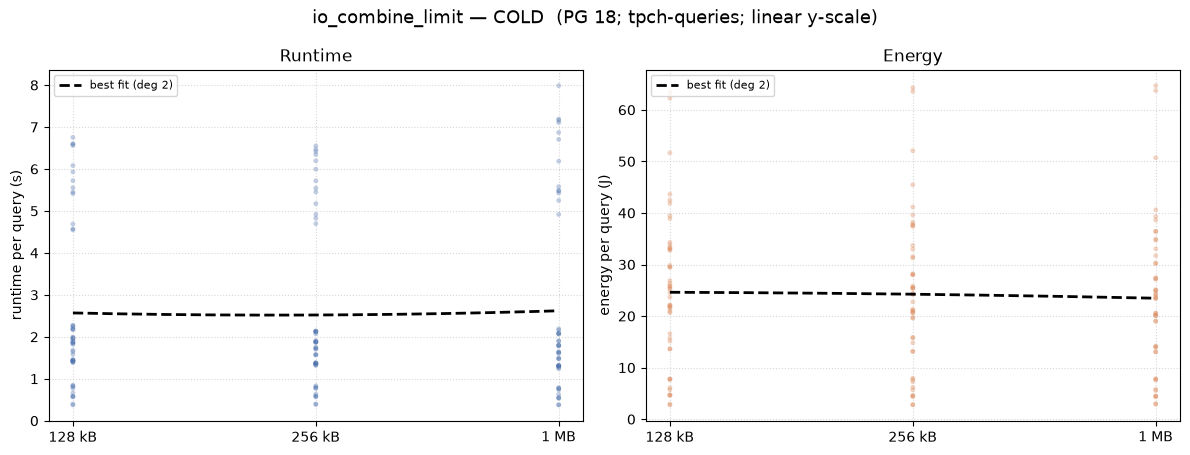

saved presentation\fig3_iom.png


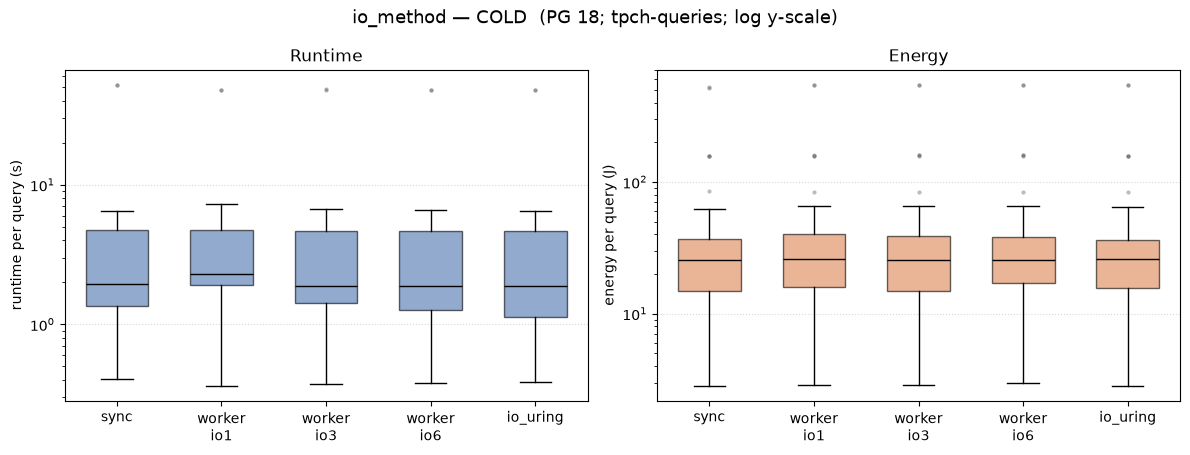

saved presentation\fig3_iom_linear.png


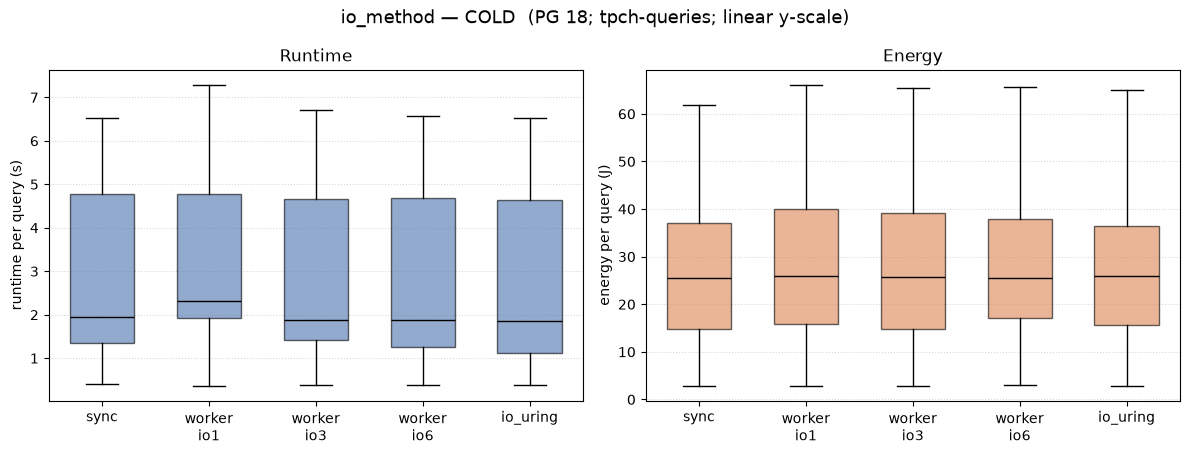

saved presentation\fig3_plp.png


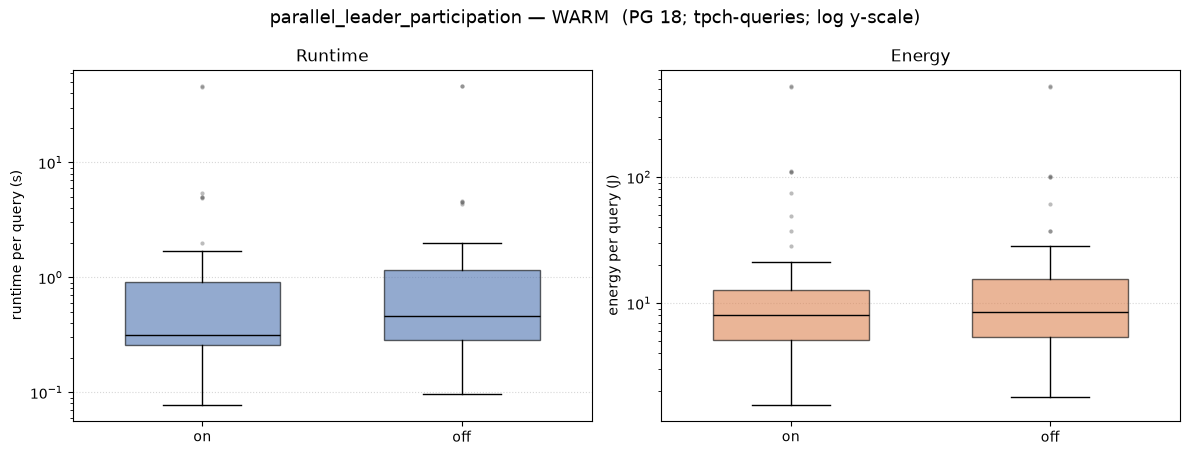

saved presentation\fig3_plp_linear.png


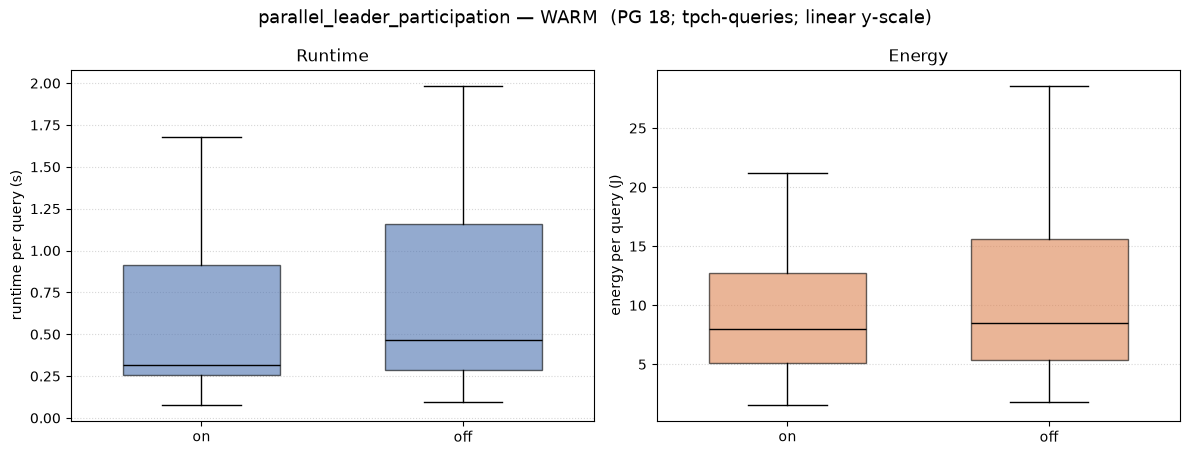

In [4]:
PG_MAJOR = "18"         # <-- parameter sweeps are PG18; change if needed
FIT_DEGREE = 2          # <-- best-fit polynomial degree: 1 = straight line, 2+ = curved

for cfg in PARAMS:
    dfp = load_param(cfg, PG_MAJOR)
    if dfp is None or dfp["value"].nunique() < 1:
        print("skip (no data):", cfg["name"]); continue
    for logy in (True, False):                       # log-scale + linear-scale versions
        suffix, sc = ("", "log") if logy else ("_linear", "linear")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
        if cfg["kind"] == "cat":
            uvals = sorted(dfp["value"].unique())
            labs = [dfp[dfp["value"] == v]["label"].iloc[0] for v in uvals]
            box(axes[0], [dfp[dfp["value"] == v]["t"].to_numpy() for v in uvals], labs, "runtime per query (s)", C_RUN, logy=logy)
            box(axes[1], [dfp[dfp["value"] == v]["e"].to_numpy() for v in uvals], labs, "energy per query (J)", C_ENE, logy=logy)
        else:
            scatter_fit(axes[0], dfp, "t", "runtime per query (s)", C_RUN, logy=logy, degree=FIT_DEGREE)
            scatter_fit(axes[1], dfp, "e", "energy per query (J)", C_ENE, logy=logy, degree=FIT_DEGREE)
        axes[0].set_title("Runtime"); axes[1].set_title("Energy")
        fig.suptitle(f"{cfg['name']} — {cfg['temp'].upper()}  (PG {PG_MAJOR}; tpch-queries; {sc} y-scale)", fontsize=13)
        fig.tight_layout(); savefig(fig, f"fig3_{cfg['prefix']}{suffix}")

## 4. Indexing — minimally indexed vs indexed (tpch-queries)

Uses the **effective_cache_size** dataset (that parameter had ~no effect, so its
runs are a clean minimally-indexed-vs-indexed comparison; per-query metrics are
pooled across its settings). **`minimally indexed`** = the small default index set
(only a few indexes) on the `tpch` schema; **`indexed`** = the `tpch_idx` schema
with the extra secondary indexes. Boxplot, runtime + energy.

saved presentation\fig4_indexing.png


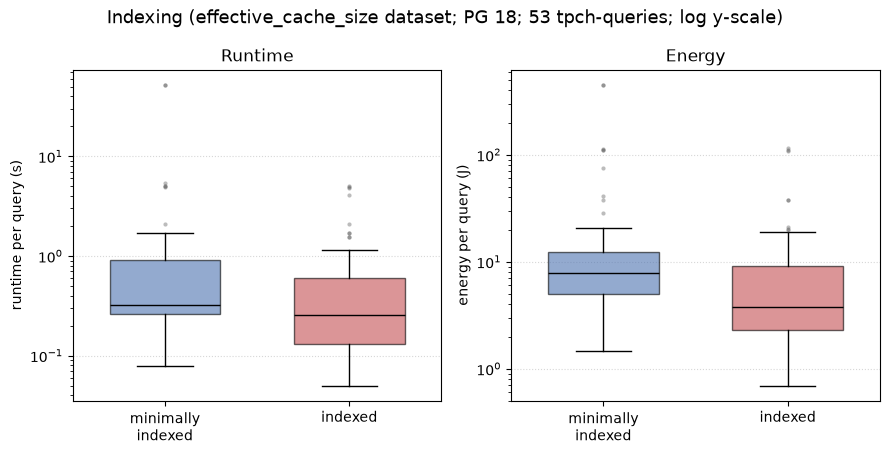

saved presentation\fig4_indexing_linear.png


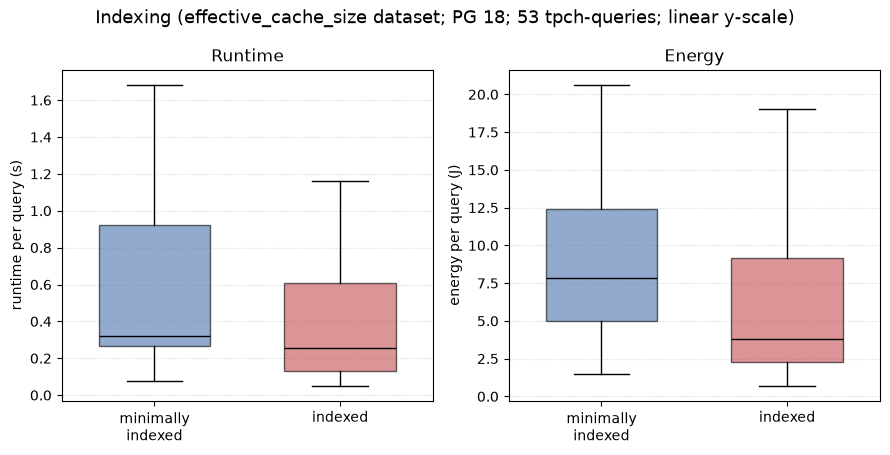

In [5]:
PG_MAJOR = "18"         # <-- change if needed
ECS = Path("ecs_cache")

def load_idx(variant):
    rows = []
    for folder in sorted(ECS.glob("ecs_*")):
        f = folder / f"query_timing_{variant}.csv"
        if not f.exists():
            continue
        d = pd.read_csv(f)
        if PG_MAJOR:
            d = d[d["pg_version"].map(ver_major) == str(PG_MAJOR)]
        if len(d):
            rows.append(warm_per_query(d))
    if not rows:
        return None
    return pd.concat(rows).groupby("query", as_index=False).agg(t=("t", "mean"), e=("e", "mean"))

base, idx = load_idx("tpch"), load_idx("tpch_idx")
if base is None or idx is None:
    print("effective_cache_size base/idx data missing")
else:
    labs = ["minimally\nindexed", "indexed"]
    for logy in (True, False):
        suffix, sc = ("", "log") if logy else ("_linear", "linear")
        fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
        box(axes[0], [base["t"], idx["t"]], labs, "runtime per query (s)", [C_WARM, "#c44e52"], logy=logy)
        box(axes[1], [base["e"], idx["e"]], labs, "energy per query (J)", [C_WARM, "#c44e52"], logy=logy)
        axes[0].set_title("Runtime"); axes[1].set_title("Energy")
        fig.suptitle(f"Indexing (effective_cache_size dataset; PG {PG_MAJOR}; {len(base)} tpch-queries; {sc} y-scale)",
                     fontsize=13)
        fig.tight_layout(); savefig(fig, f"fig4_indexing{suffix}")

## 5. Warm vs cold

Left/centre: boxplots of per-query **runtime** and **energy**, warm vs cold, on a
common query set. Then a second figure breaks the mean per-query time into
**server planning → server execution (runtime) → client overhead** for warm and
cold.

saved presentation\fig5_warmcold.png


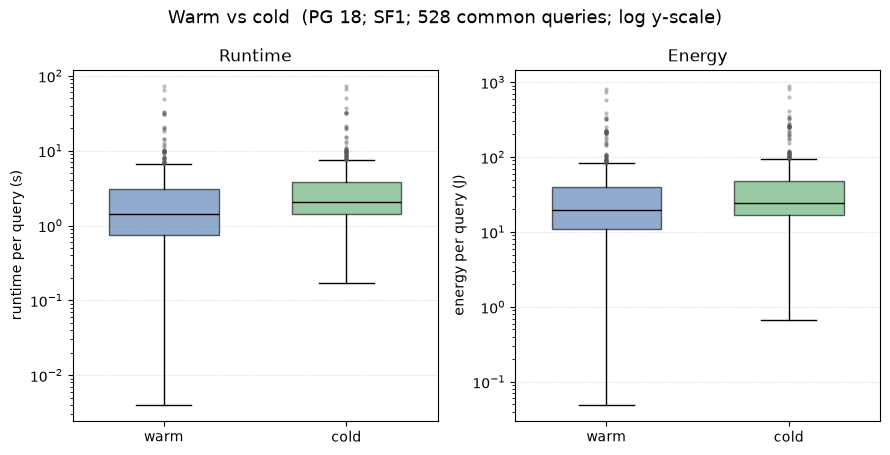

saved presentation\fig5_warmcold_linear.png


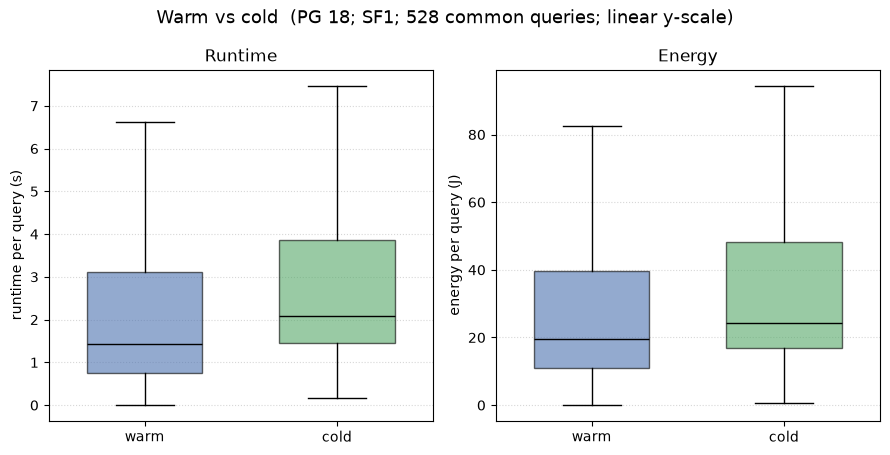

saved presentation\fig5_warmcold_components.png


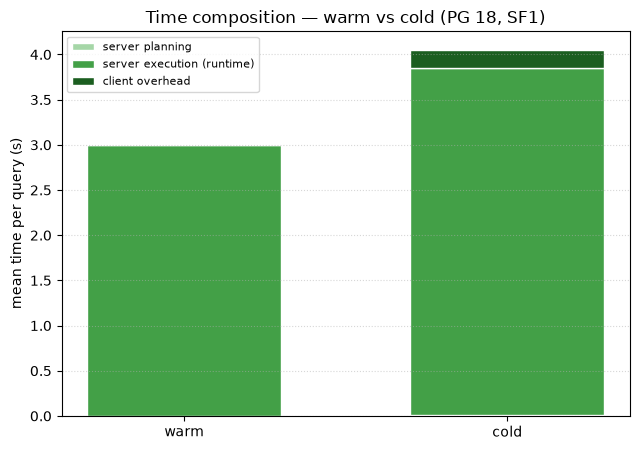

In [6]:
PG_MAJOR = "18"         # <-- change if needed
SCALE = "tpch"          # <-- SF1

warm = load_scale(SCALE, "warm", PG_MAJOR)
cold = load_scale(SCALE, "cold", PG_MAJOR)
if warm is None or cold is None:
    print("warm or cold data missing for", SCALE)
else:
    common = set(warm["query"]) & set(cold["query"])
    w = warm[warm["query"].isin(common)]; c = cold[cold["query"].isin(common)]
    for logy in (True, False):
        suffix, sc = ("", "log") if logy else ("_linear", "linear")
        fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
        box(axes[0], [w["t"], c["t"]], ["warm", "cold"], "runtime per query (s)", [C_WARM, C_COLD], logy=logy)
        box(axes[1], [w["e"], c["e"]], ["warm", "cold"], "energy per query (J)", [C_WARM, C_COLD], logy=logy)
        axes[0].set_title("Runtime"); axes[1].set_title("Energy")
        fig.suptitle(f"Warm vs cold  (PG {PG_MAJOR}; {SCALES.get(SCALE, SCALE)}; {len(common)} common queries; {sc} y-scale)",
                     fontsize=13)
        fig.tight_layout(); savefig(fig, f"fig5_warmcold{suffix}")

    # --- component breakdown (mean per-query seconds) ---
    wc = warm_components(SCALE, PG_MAJOR)
    cc = cold_components(SCALE, PG_MAJOR)
    comp_labels = ["server planning", "server execution (runtime)", "client overhead"]
    seg_cols = ["#a5d6a7", "#43a047", "#1b5e20"]
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    for xi, (name, s) in enumerate([("warm", wc), ("cold", cc)]):
        bottom = 0.0
        for k, (lab, col) in enumerate(zip(comp_labels, seg_cols)):
            v = float(s.iloc[k])
            ax.bar(xi, v, bottom=bottom, color=col, edgecolor="white",
                   label=lab if xi == 0 else None, width=0.6)
            bottom += v
    ax.set_xticks([0, 1]); ax.set_xticklabels(["warm", "cold"])
    ax.set_ylabel("mean time per query (s)")
    ax.set_title(f"Time composition — warm vs cold (PG {PG_MAJOR}, {SCALES.get(SCALE, SCALE)})")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle=":", alpha=0.5)
    fig.tight_layout(); savefig(fig, "fig5_warmcold_components")